# Exploration des KPI de l'ETL

Ce notebook explore les métriques enregistrées à chaque exécution du pipeline de transformation (`pipeline.metrics`, fichier `data/metrics/etl_runs.jsonl`) selon les trois axes demandés :
- **Précision** — part des lignes valides après nettoyage, détail des causes de rejet
- **Rapidité** — temps total et temps par étape (lecture, adaptation, nettoyage, enrichissement, export)
- **Coût** — mémoire pic utilisée par exécution

C'est le pendant technique/exploratoire du dashboard grand public [`streamlit_dashboard.py`](../streamlit_dashboard.py) (à lancer avec `streamlit run streamlit_dashboard.py`) — les deux lisent la même source de données.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import pandas as pd

from pipeline.metrics import DEFAULT_METRICS_PATH, load_metrics

METRICS_PATH = PROJECT_ROOT / DEFAULT_METRICS_PATH
runs = load_metrics(METRICS_PATH)
print(f"{len(runs)} exécution(s) enregistrée(s), {runs['source'].nunique() if len(runs) else 0} source(s)")
runs.head()

3 exécution(s) enregistrée(s), 3 source(s)


,source,run_timestamp,duration_seconds,step_durations,rows_read,rows_exported,pct_valid,rows_dropped_missing_text,rows_dropped_duplicate,rows_dropped_label,peak_memory_mb
0,google_factcheck,2026-09-17 09:22:33+00:00,0.1626,"{'read': 0.0543, 'adapt': 0.0022, 'clean': 0.0...",772,772,100.00,0,0,0,102.69
1,isot,2026-09-17 09:23:04+00:00,8.3642,"{'read': 1.0216, 'adapt': 0.008700000000000001...",44898,38726,86.25,0,6172,0,390.05
2,fakenewsnet_politifact_true,2026-09-17 09:23:55+00:00,0.0560,"{'read': 0.0216, 'adapt': 0.0025, 'clean': 0.0...",9,9,100.00,0,0,0,179.06


## 1. Précision — part de données valides

`pct_valid = lignes exportées / lignes lues brutes`. Le détail des rejets (texte manquant, doublon, label non reconnu) explique pourquoi une source perd des lignes.

In [3]:
latest_per_source = runs.sort_values("run_timestamp").groupby("source").tail(1).set_index("source")
latest_per_source[["pct_valid", "rows_read", "rows_exported"]]

,pct_valid,rows_read,rows_exported
source,,,
google_factcheck,100.00,772,772
isot,86.25,44898,38726
fakenewsnet_politifact_true,100.00,9,9


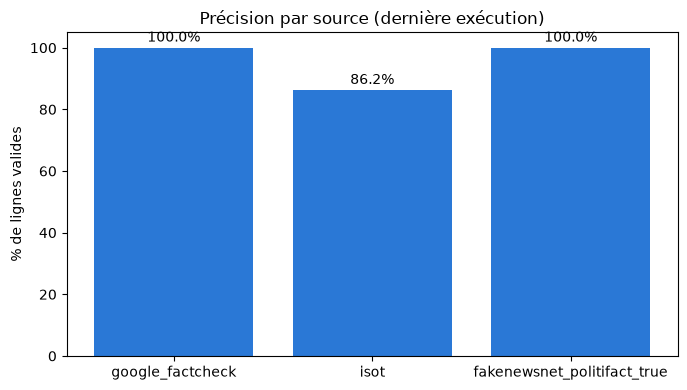

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(latest_per_source.index, latest_per_source["pct_valid"], color="#2a78d6")
ax.set_ylabel("% de lignes valides")
ax.set_ylim(0, 105)
ax.set_title("Précision par source (dernière exécution)")
for i, value in enumerate(latest_per_source["pct_valid"]):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

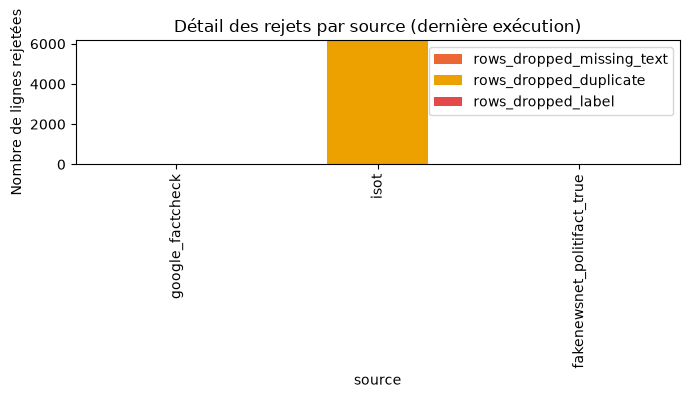

In [5]:
drop_columns = ["rows_dropped_missing_text", "rows_dropped_duplicate", "rows_dropped_label"]
latest_per_source[drop_columns].plot(
    kind="bar", stacked=True, figsize=(7, 4), color=["#eb6834", "#eda100", "#e34948"]
)
plt.ylabel("Nombre de lignes rejetées")
plt.title("Détail des rejets par source (dernière exécution)")
plt.tight_layout()
plt.show()

## 2. Rapidité — temps total et par étape

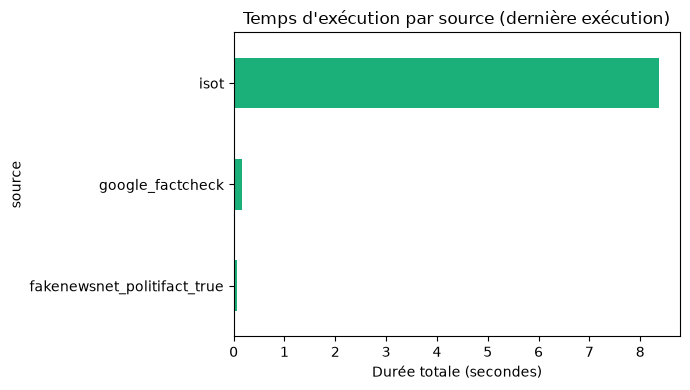

In [6]:
latest_per_source["duration_seconds"].sort_values().plot(
    kind="barh", figsize=(7, 4), color="#1baf7a"
)
plt.xlabel("Durée totale (secondes)")
plt.title("Temps d'exécution par source (dernière exécution)")
plt.tight_layout()
plt.show()

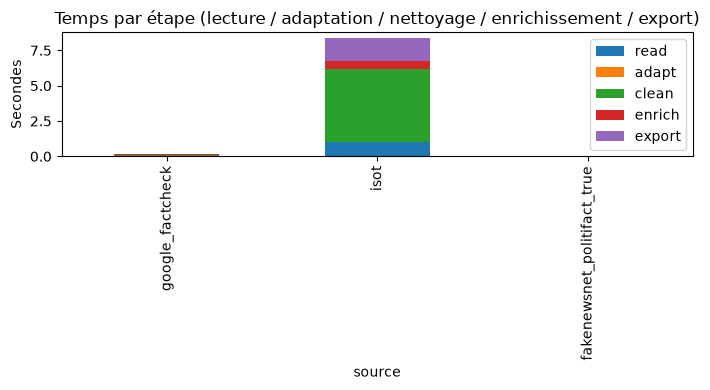

,read,adapt,clean,enrich,export
source,,,,,
google_factcheck,0.0543,0.0022,0.0694,0.0110,0.0237
isot,1.0216,0.0087,5.1420,0.5499,1.6387
fakenewsnet_politifact_true,0.0216,0.0025,0.0172,0.0035,0.0091


In [7]:
steps_df = pd.json_normalize(latest_per_source["step_durations"]).set_index(latest_per_source.index)
steps_df.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.ylabel("Secondes")
plt.title("Temps par étape (lecture / adaptation / nettoyage / enrichissement / export)")
plt.tight_layout()
plt.show()
steps_df

## 3. Coût — mémoire pic

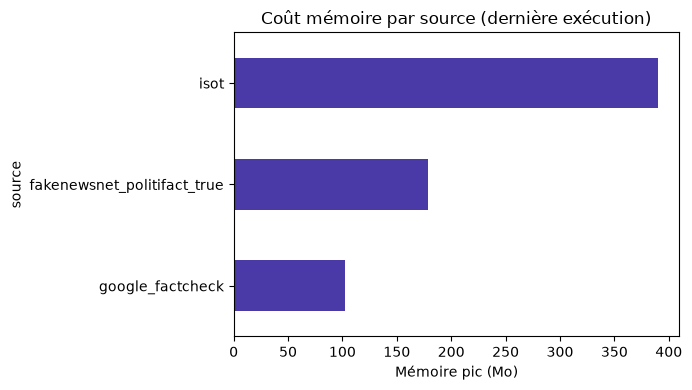

In [8]:
latest_per_source["peak_memory_mb"].sort_values().plot(
    kind="barh", figsize=(7, 4), color="#4a3aa7"
)
plt.xlabel("Mémoire pic (Mo)")
plt.title("Coût mémoire par source (dernière exécution)")
plt.tight_layout()
plt.show()

## 4. Évolution dans le temps (si plusieurs exécutions par source)

Utile pour repérer une dérive : une source qui devient plus lente, ou dont le taux de validité chute d'un run à l'autre.

Pas encore assez d'exécutions répétées par source pour tracer une tendance.


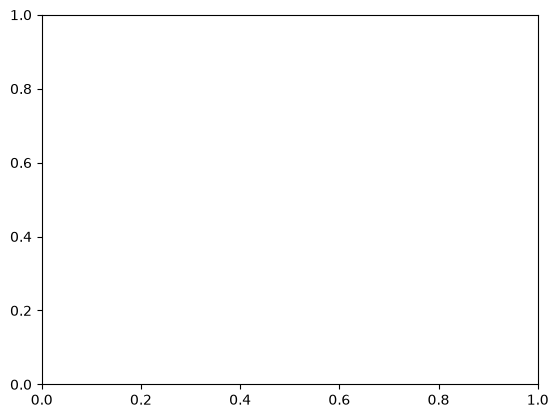

In [9]:
for source, group in runs.sort_values("run_timestamp").groupby("source"):
    if len(group) > 1:
        plt.plot(group["run_timestamp"], group["pct_valid"], marker="o", label=source)

if plt.gca().lines:
    plt.ylabel("% de lignes valides")
    plt.title("Évolution de la précision dans le temps")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Pas encore assez d'exécutions répétées par source pour tracer une tendance.")

## 5. Résumé agrégé

In [10]:
summary = (
    runs.groupby("source")
    .agg(
        executions=("run_timestamp", "count"),
        pct_valid_moyen=("pct_valid", "mean"),
        duree_moyenne_s=("duration_seconds", "mean"),
        memoire_pic_moyenne_mo=("peak_memory_mb", "mean"),
    )
    .round(2)
)
summary

,executions,pct_valid_moyen,duree_moyenne_s,memoire_pic_moyenne_mo
source,,,,
fakenewsnet_politifact_true,1,100.00,0.06,179.06
google_factcheck,1,100.00,0.16,102.69
isot,1,86.25,8.36,390.05
